In [17]:
import sys
import os

# Adds the parent directory to the search path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import xtrack as xt
import numpy as np
import matplotlib.pyplot  as plt
import matplotlib.patches as patches
import xpart as xp
import xobjects as xo
import math
from TuneDiagram.lib.TuneDiagram.tune_diagram import resonance_lines
from prettytable import PrettyTable
import xutil_DA_CC.xsuite_plot_functions as my_xpf
import xutil_DA_CC.xsuite_utilities as xutil
import constants
import sextupole_configs as sc
import my_functions as mf
import matplotlib.collections as mcol  
import matplotlib.lines as mlines      
import matplotlib.cm as mcm   
import linear_optics_variation_2 as lo2
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd
import json

In [18]:
#Macro particle distribution
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, "Macro-particle distributions", "PositronBeam_2p86GeV", "Beam_3GHzOption_2.86GeV_20260421.dat")
file_path_tw = os.path.join(parent_dir, "Macro-particle distributions","TwissResults.json")


df = pd.read_csv(file_path, sep=r'\s+')
df_twiss=pd.read_json(file_path_tw)

In [19]:
n=1
pdf_run=False

if pdf_run is True:
    pdf = PdfPages(f"config_D{n}/config_D{n}_using_particle_dist.pdf")

    _old_savefig = plt.savefig

    def _new_savefig(*args, **kwargs):
        pdf.savefig(plt.gcf())
        _old_savefig(*args, **kwargs)

    plt.savefig = _new_savefig

In [20]:
pdr= xt.Environment.from_json("json_files/pdr_var2.json")


#Sextupole configuration implementation
sc.config_D1(pdr)


ring=pdr.lines['ring']
print(ring.element_names)
period=pdr.lines['period']

Loading line from dict:   0%|          | 0/2981 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
['QFA_1RC', 'Drarc', 'Bend1_1R1', 'Drarc', 'QDA_1R1', 'Drarc', 'Bend2_1R1', 'Drarc', 'QFA_1R1', 'Drarc', 'Bend1_1R2', 'Drarc', 'QDA_1R2', 'Drarc', 'Bend2_1R2', 'Drarc', 'QFA_1R2', 'Drarc', 'Bend1_1R3', 'Drarc', 'QDA_1R3', 'Drarc', 'Bend2_1R3', 'Drarc', 'QFA_1R3', 'Drarc', 'Bend1_1R4', 'Drarc', 'QDA_1R4', 'Drarc', 'Bend2_1R4', 'Drarc', 'QFA_1R4', 'Drarc', 'Bend1_1R5', 'Drarc', 'QDA_1R5', 'Drarc', 'Bend2_1R5', 'Drarc', 'QFA_1R5', 'Drarc', 'Bend1_1R6', 'Drarc', 'QDA_1R6', 'Drarc', 'Bend2_1R6', 'Drarc', 'QFA_1R6', 'Drarc', 'Bend1_1R7', 'Drarc', 'QDA_1R7', 'Drarc', 'Bend2_1R7', 'Drarc', 'QFA_M1R7', 'Drarc', 'Bend1_1R8', 'Drarc', 'QDA_M1R8', 'Drarc', 'Bend2_1R8', 'DrarcS', 'QFDS_1R', 'DrDSL', 'QDDS_1R', 'Drarc', 'BendDS_1R', 'DrTrans', 'QFDoub_1R', 'DrDoub', 'QDDoub_1R', 'DrTripl..164', 'RFCav_1', 'DrTripl..166', 'QDTrip_1R1', 'DrTrip

Slicing line:   0%|          | 0/458 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/460 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/462 [00:00<?, ?it/s]

...

Slicing line:   0%|          | 0/210 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/212 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/214 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/216 [00:00<?, ?it/s]

Correcting linear chromaticity to zero...
                                             
Optimize - start penalty: 28.31                             
Matching: model call n. 21 penalty = 3.1399e-05              
Optimize - end penalty:  3.13985e-05                            
Final k2XF2arc: 91.926868
Final k2XD2arc: -121.033616
('QFA_1RC', 'Drarc..1230', 'XF2arc_1RC', 'Drarc..1232', 'Bend1_1R1', 'Drarc', 'QDA_1R1', 'Drarc..960', 'XD2arc_1R1', 'Drarc..962', 'Bend2_1R1', 'Drarc', 'QFA_1R1', 'Drarc..1104', 'XF2arc_1R1', 'Drarc..1106', 'Bend1_1R2', 'Drarc', 'QDA_1R2', 'Drarc..963', 'XD2arc_1R2', 'Drarc..965', 'Bend2_1R2', 'Drarc', 'QFA_1R2', 'Drarc..1107', 'XF2arc_1R2', 'Drarc..1109', 'Bend1_1R3', 'Drarc', 'QDA_1R3', 'Drarc..966', 'XD2arc_1R3', 'Drarc..968', 'Bend2_1R3', 'Drarc', 'QFA_1R3', 'Drarc..1110', 'XF2arc_1R3', 'Drarc..1112', 'Bend1_1R4', 'Drarc', 'QDA_1R4', 'Drarc..969', 'XD2arc_1R4', 'Drarc..971', 'Bend2_1R4', 'Drarc', 'QFA_1R4', 'Drarc..1113', 'XF2arc_1R4', 'Drarc..1115', 'Bend1

In [21]:
E0 = constants.E0; VRF = constants.VRF

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )


ring.configure_radiation(model=None)
fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz

sc.insert_BPMs_all_as_markers(pdr)
sc.insert_correctors(pdr)

tw_init = xt.TwissInit(
    alfx=df_twiss['x']['alpha'], 
    betx=df_twiss['x']['beta'], 
    alfy=df_twiss['y']['alpha'], 
    bety=df_twiss['y']['beta'],
    dx=df_twiss['x']['dispersion'], 
    #dpx=df_twiss['x']['dispersion_prime'],
    #dy=df_twiss['y']['dispersion'], 
    #dpy=df_twiss['y']['dispersion_prime']
)

period_twiss=period.twiss4d(alfx=df_twiss['x']['alpha'], betx=df_twiss['x']['beta'], alfy=df_twiss['y']['alpha'], bety=df_twiss['y']['beta'],
                 dx=df_twiss['x']['dispersion'], dpx=df_twiss['x']['dispersion_prime'],dy=df_twiss['y']['dispersion'], dpy=df_twiss['y']['dispersion_prime'])


#mf.misalignments(ring)




#lo2.matchingWP(*constants.WP)

'''cell_tr=pdr.lines['cell_tr']
cell_tr_tw = cell_tr.twiss(method='4d')
mid_idx = len(cell_tr_tw.betx) // 2
betxS = cell_tr_tw.betx[mid_idx]
betyS = cell_tr_tw.bety[mid_idx]
lo2.matchingBeta( betxS, betyS, MakePlot=False )'''

Slicing line:   0%|          | 0/218 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/644 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/645 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/646 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/647 [00:00<?, ?it/s]

...

Slicing line:   0%|          | 0/1028 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/1030 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/1032 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/1034 [00:00<?, ?it/s]

"cell_tr=pdr.lines['cell_tr']\ncell_tr_tw = cell_tr.twiss(method='4d')\nmid_idx = len(cell_tr_tw.betx) // 2\nbetxS = cell_tr_tw.betx[mid_idx]\nbetyS = cell_tr_tw.bety[mid_idx]\nlo2.matchingBeta( betxS, betyS, MakePlot=False )"

In [22]:

'''
ring.discard_tracker()
try:
    sc.orbit_correction(pdr,twiss,threading=False)
    
except:
    sc.orbit_correction(pdr,twiss,threading=True)
    
lo2.matchingWP(*constants.WP)'''
#lo2.matchingWP(*constants.WP)

'\nring.discard_tracker()\ntry:\n    sc.orbit_correction(pdr,twiss,threading=False)\n\nexcept:\n    sc.orbit_correction(pdr,twiss,threading=True)\n\nlo2.matchingWP(*constants.WP)'

In [23]:


ring.configure_radiation(model='mean')


#ring.cycle(name_first_element='QDDoub_3L', inplace=True)
ring_tw=ring.twiss(method='6d', init=tw_init, init_at='BPMy_QDDoub_3L',disable_apertures=True,
    _continue_if_lost=True)
#ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
 #                  spin=True, polarization=True )

/home/mwatson/.local/lib/python3.12/site-packages/xtrack/twiss.py:4786: RuntimeWarning: invalid value encountered in divide
  v1[:, ii] /= nux
/home/mwatson/.local/lib/python3.12/site-packages/xtrack/twiss.py:4787: RuntimeWarning: invalid value encountered in divide
  v2[:, ii] /= nuy
/home/mwatson/.local/lib/python3.12/site-packages/xtrack/twiss.py:4788: RuntimeWarning: invalid value encountered in divide
  v3[:, ii] /= nuzeta


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/mwatson/ipykernel_1105925/2200527083.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(ring_tw.s, sigma_x * 1000, label='3-$\sigma$ Beam Envelope')


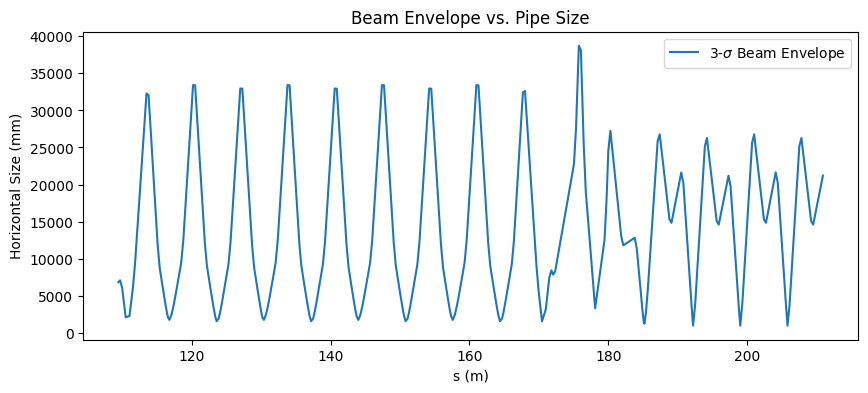

In [24]:

# Calculate the 3-sigma horizontal envelope
# Using geometric emittance (ex) and dispersion (dx) from your beam
sigma_x = np.sqrt(ring_tw.betx * df_twiss['x']['emittance_geo'] + (ring_tw.dx * 5.88)**2)

plt.figure(figsize=(10, 4))
plt.plot(ring_tw.s, sigma_x * 1000, label='3-$\sigma$ Beam Envelope')
# If your ring has aperture data:
if 'x_max' in ring_tw.to_pandas().columns:
    plt.plot(ring_tw.s, ring_tw.x_max * 1000, 'r', label='Aperture Limit')

plt.ylabel('Horizontal Size (mm)')
plt.xlabel('s (m)')
plt.legend()
plt.title('Beam Envelope vs. Pipe Size')
plt.show()

In [25]:
print(ring.element_names)

('QFA_1RC', 'BPMx_QFA_1RC', 'Drarc..1230', 'XF2arc_1RC_entry', 'XF2arc_1RC..entry_map', 'XF2arc_1RC..0', 'Mx_QFA_1RC', 'XF2arc_1RC..1', 'XF2arc_1RC..exit_map', 'XF2arc_1RC_exit', 'Drarc..1232', 'Bend1_1R1', 'Drarc..1655', 'My_QDA_1R1', 'Drarc..1656', 'QDA_1R1', 'BPMy_QDA_1R1', 'Drarc..960', 'XD2arc_1R1', 'Drarc..962', 'Bend2_1R1', 'Drarc..1751', 'Mx_QFA_1R1', 'Drarc..1752', 'QFA_1R1', 'BPMx_QFA_1R1', 'Drarc..1104', 'XF2arc_1R1', 'Drarc..1106', 'Bend1_1R2', 'Drarc..1657', 'My_QDA_1R2', 'Drarc..1658', 'QDA_1R2', 'BPMy_QDA_1R2', 'Drarc..963', 'XD2arc_1R2', 'Drarc..965', 'Bend2_1R2', 'Drarc..1753', 'Mx_QFA_1R2', 'Drarc..1754', 'QFA_1R2', 'BPMx_QFA_1R2', 'Drarc..1107', 'XF2arc_1R2', 'Drarc..1109', 'Bend1_1R3', 'Drarc..1659', 'My_QDA_1R3', 'Drarc..1660', 'QDA_1R3', 'BPMy_QDA_1R3', 'Drarc..966', 'XD2arc_1R3', 'Drarc..968', 'Bend2_1R3', 'Drarc..1755', 'Mx_QFA_1R3', 'Drarc..1756', 'QFA_1R3', 'BPMx_QFA_1R3', 'Drarc..1110', 'XF2arc_1R3', 'Drarc..1112', 'Bend1_1R4', 'Drarc..1661', 'My_QDA_1R4', 'D

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


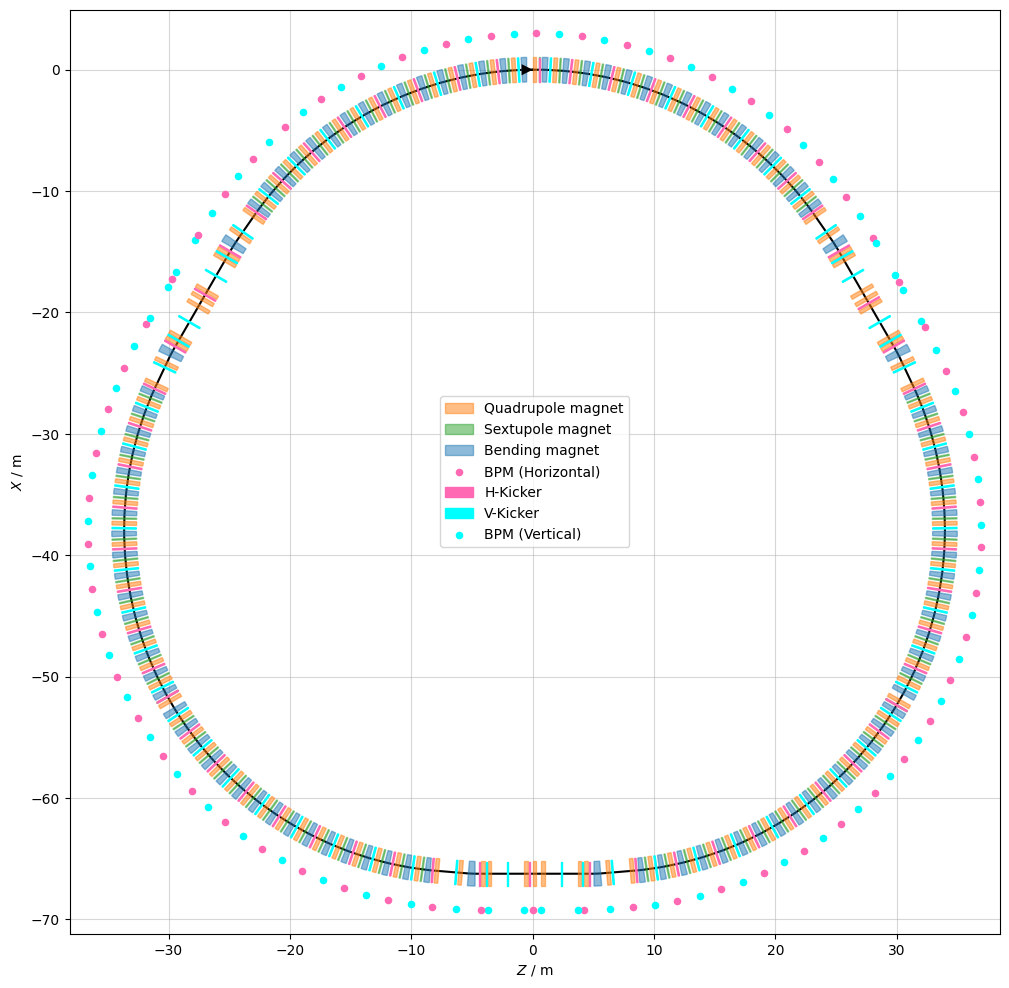

<Figure size 640x480 with 0 Axes>

In [26]:
#%matplotlib widget
#ring.survey().plot(labels=ring.element_names)
mf.survey_plot(ring)
#plt.tight_layout()
plt.savefig(f'config_D{n}/ring_survey_{n}.png')
#mf.survey_plot_with_strength(ring, scale_height=5.0)

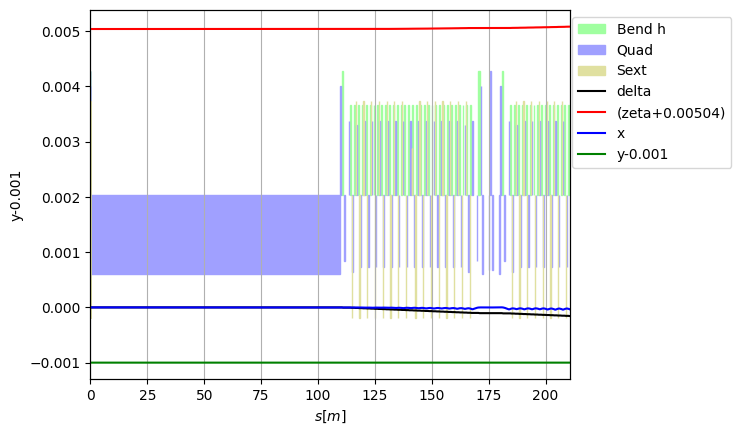

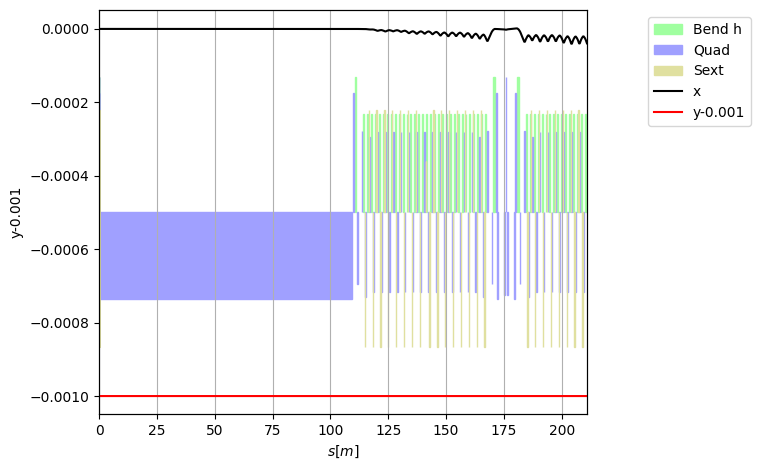

In [27]:

ring_tw.plot(f'delta (zeta+0.00504) x y-0.001')
ring_tw.plot(f'x y-0.001')
plt.tight_layout()
plt.savefig(f'config_D{n}/ring_closed_orbit_perfect{n}.png')


AttributeError: Cannot find `dqx` in table

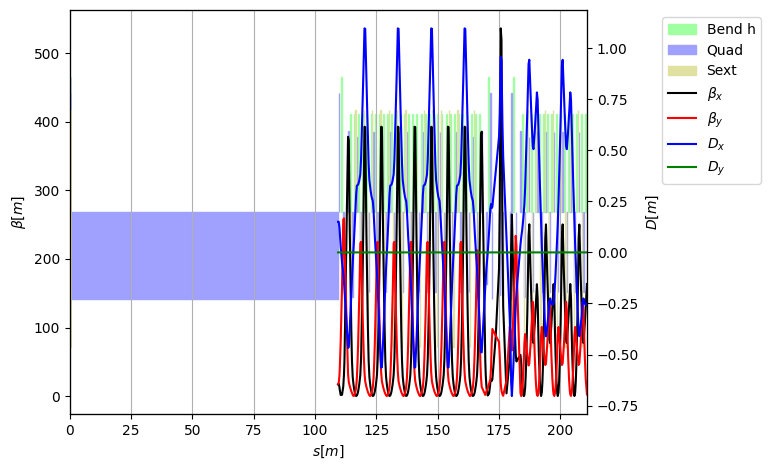

In [28]:

ring_tw.plot()
plt.tight_layout()
plt.savefig(f'config_D{n}/ring_twiss_{n}.png')


def calc_damping_time_constant(m):
    num=2*E0*ring_tw.T_rev0
    den=ring_tw.partition_numbers[m]*U0
    tau=num/den
    return tau

# Initialize the table
brho = ring.particle_ref.p0c[0] / 299792458.0 
max_k0 = np.max(np.abs(ring_tw.k0l))
max_field_tesla = max_k0 * brho
# 1. Prepare your data in a list of lists
data = [
    ["Horizontal Chromaticity (dqx)", f"{ring_tw.dqx:.4f}", ""],
    ["Vertical Chromaticity (dqy)", f"{ring_tw.dqy:.4f}", ""],
    ["Max Betx", f"{max(ring_tw.betx):.2f}", "m"],
    ["Max Bety", f"{max(ring_tw.bety):.2f}", "m"],
    ["Harmonic Number", f"{fRF/fRev:10.5f}", ""],
    ["RF Frequency", f"{fRF*1e-6:8.5f}", "MHz"],
    ["Length of short drifts", f"{pdr['l_drift']:7.3f}", "m"],
    ["Circumference", f"{ring_tw.circumference:8.4f}", "m"],
    ["Revolution Time", f"{1e6*ring_tw.T_rev0:8.5f}", "us"],
    ["Energy Loss (Manual)", f"{U0*1e-3:10.2f}", "keV"],
    ["Energy Loss (Twiss)", f"{ring_tw.eneloss_turn:10.2f}", "keV"],
    ["Vertical Damping Time", f"{1/ring_tw.damping_constants_turns[1]:10.3f}", "turns"],
    ["Horizontal Tune (qx)", f"{ring_tw.qx:10.5f}", ""],
    ["Vertical Tune (qy)", f"{ring_tw.qy:10.5f}", ""],
    ["Equilibrium Polarization", f"{ring_tw.spin_polarization_eq:8.5f}", ""],
    ["Equilibrium Emittance x", f"{ring_tw.eq_gemitt_x * 1e9:.4f}", "nm"],
    ["Equilibrium Emittance y", f"{ring_tw.eq_gemitt_y * 1e9:.4f}", "nm"],
    ["Polarization Build-up Time", f"{(ring_tw.spin_t_pol_buildup_s)/60:10.2f}", "minutes"],
    ["Horiz. Damping Constant", f"{(1/ring_tw.damping_constants_s[0])*1e3:.5f}", "ms"],
    ["Vert. Damping Constant", f"{(1/ring_tw.damping_constants_s[1])*1e3:.5f}", "ms"],
    ["Long. Damping Constant", f"{(1/ring_tw.damping_constants_s[2])*1e3:.5f}", "ms"],
    ["Maximum bending field", f"{max_field_tesla:.4f}", "T"]
]

column_headers = ["Parameter", "Value", "Unit"]

betx0 = ring_tw.betx[0]
bety0 = ring_tw.bety[0]
alfx0 = ring_tw.alfx[0]
alfy0 = ring_tw.alfy[0]


print(f"Initial Beta X: {betx0:.4f} m")
print(f"Initial Alpha X: {alfx0:.4f}")
print(f"Initial Beta Y: {bety0:.4f} m")
print(f"Initial Alpha Y: {alfy0:.4f}")
dx_start = ring_tw.dx[0]
dpx_start = ring_tw.dpx[0]

print(f"Initial Periodic Dispersion x:  {dx_start:.6f} m")
print(f"Initial Periodic Dispersion px: {dpx_start:.6f}")

# To verify it is periodic, check the last element as well
dx_end = ring_tw.dx[-1]
print(f"End Periodic Dispersion x:      {dx_end:.6f} m")

# 2. Create the figure
fig, ax = plt.subplots(figsize=(8, 10)) # Adjust size to fit your rows
ax.axis('tight')
ax.axis('off')

# 3. Create the table
table = ax.table(
    cellText=data, 
    colLabels=column_headers, 
    cellLoc='center', 
    loc='center'
)

# 4. Optional: Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5) # Scale width and height of cells

# Bold the headers
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.savefig(f'config_D{n}/table_results_D{n}.png')


#Working point plot
resonance_orders = (1,2,3,4)
Qx_range = (15,16)
Qy_range = (15,16)
resonances = resonance_lines(Qx_range,Qy_range,resonance_orders,3)
fig, ax = plt.subplots(1, figsize=(8,8), alpha=0.3)
ax.plot(ring_tw.qx, ring_tw.qy,'o', 
                color='green', label='Current working point', markersize=5)
ax.legend()
resonances.plot_resonance(fig)
plt.tight_layout()
plt.savefig(f'config_D{n}/working_point_{n}.png')

print('2nd order chrom x', ring_tw.ddqx)
print('2nd order chrom y', ring_tw.ddqy)

Best Injection Point: QFA_1RC at s = 0.000 m
Mismatch Factor at this point: nan


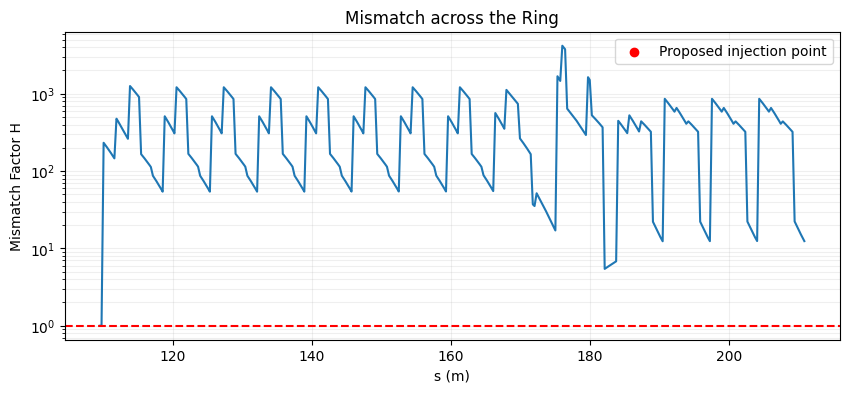

In [29]:


b_beam = df_twiss['x']['beta']
a_beam = df_twiss['x']['alpha']
g_beam = (1 + a_beam**2) / b_beam


beta_ring = ring_tw.betx
alpha_ring = ring_tw.alfx
gamma_ring = (1 + alpha_ring**2) / beta_ring

mismatch = 0.5 * (beta_ring*g_beam - 2*alpha_ring*a_beam + gamma_ring*b_beam)

best_idx = np.argmin(mismatch)
best_s = ring_tw.s[best_idx]
best_element = ring_tw.name[best_idx]

print(f"Best Injection Point: {best_element} at s = {best_s:.3f} m")
print(f"Mismatch Factor at this point: {mismatch[best_idx]:.4f}")


plt.figure(figsize=(10, 4))
plt.plot(ring_tw.s, mismatch)
plt.scatter(ring_tw.s[best_idx],mismatch[best_idx],color='red', label='Proposed injection point')
plt.axhline(1.0, color='r', linestyle='--')
plt.ylabel('Mismatch Factor H')
plt.xlabel('s (m)')
plt.title('Mismatch across the Ring')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()

'l_cell':   3.4000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5000,
'dl_drift':  -0.1000,
'l_doub':   0.2500,
'l_tripl':   2.7000,
'l_trips':   0.4000,
'l_sext':   0.1000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.9478,
'kQDarc':  -2.9231,
'kQFarcM':   2.7828,
'kQDarcM':  -3.1021,
'kQFDS':   2.9748,
'kQDDS':  -2.6516,
'kQFDoub':   4.3741,
'kQDDoub':  -3.1934,
'kQFtr':   4.9561,
'kQDtr':  -3.0337,
'k2XF2arc':  91.9269,
'k2XD2arc': -121.0336,
'l_kick':   0.1000,
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_PRCH    Quadrupo  0.1500   0.0000   0.1500   0.0000  0.0000 'kQFarc' =  2.9478  
  BPMx_QFA_PRCHBeamPosi  0.0000   0.1500   0.1500   0.1500  0.2750  None    =  0.0000  
  XF2arc_PRCH Sextupol  0.1000   0.4250   0.5250   0.2750  0.1250  None    =  0.0000  
  Bend1_PR1   Bend      0.4000   0.6500   1.0500   0.1250  0.5000  None    =  0.0000  
  QDA_PR1     Quadrupo  0.3000   1.5

<Axes: >

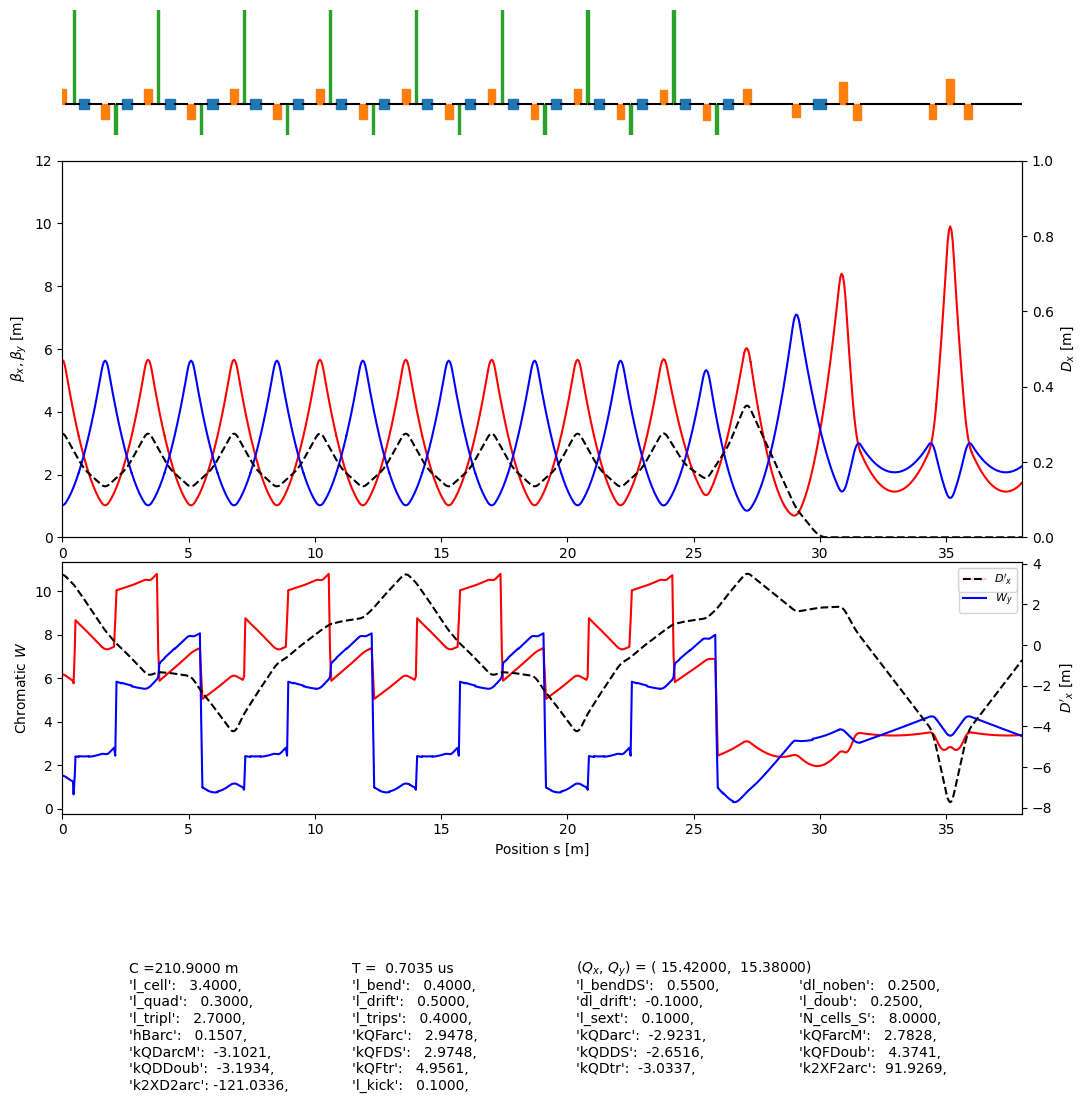

In [ ]:

mf.SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 12.), (0., 1.), .08,pdr, f"config_D{n}/Standard{n}.png" )

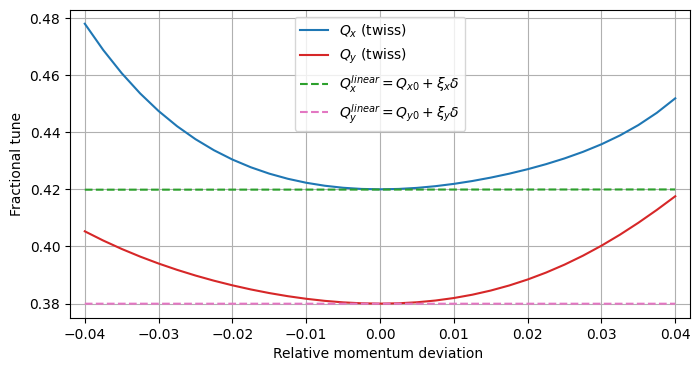

In [ ]:
max_dp = 4e-2
deltas = np.arange(-max_dp,max_dp+2.5e-3,2.5e-3)

delta=[]
qx=[]
qy=[]
qx_shift=[]
qy_shift=[]
for d in deltas:
    ring.configure_radiation(model=None)
    try:
        tw=ring.twiss4d(delta0=d)
        qx.append(tw.qx)
        qy.append(tw.qy)
        qx_s=ring_tw.qx+ring_tw.dqx*d
        qx_shift.append(qx_s)
        qy_s=ring_tw.qy+ring_tw.dqy*d
        qy_shift.append(qy_s)
        delta.append(d)
    except:
        print('deltap of %1.2e not stable'%d)


nominal_tw = ring.twiss4d(delta0=0)

plt.figure(figsize=(8,4))
WP = (nominal_tw.qx,nominal_tw.qy)
Qx_range = (np.floor(WP[0])-0.05,np.floor(WP[0])+0.55)
Qy_range = (np.floor(WP[1])-0.05,np.floor(WP[1])+0.55)

 
plt.plot(delta, qx-np.floor(WP[0]), label='$Q_x$ (twiss)', color='tab:blue')
plt.plot(delta, qy-np.floor(WP[1]), label='$Q_y$ (twiss)', color='tab:red')

# Dotted/Dashed lines for the linear model
plt.plot(delta, qx_shift-np.floor(WP[0]), '--', label=f'$Q_x^{{linear}} = Q_{{x0}} + \\xi_x \\delta$', color='tab:green')
plt.plot(delta, qy_shift-np.floor(WP[1]), '--', label=f'$Q_y^{{linear}} = Q_{{y0}} + \\xi_y \\delta$', color='tab:pink')
plt.xlabel('Relative momentum deviation ')
plt.ylabel('Fractional tune')
plt.legend()
plt.grid(True)
plt.xlim(-max_dp*1.05,max_dp*1.05)
plt.savefig(f'config_D{n}/momentum_deviation{constants.WP}.png')

In [ ]:
r_max = 16.0
fp0 = None
nemitt_x = 1.3e-3
nemitt_y = 1.2e-3 

while r_max >= 1:
    try:
        n_r = int(r_max)
        fp0 = ring.get_footprint(
            nemitt_x=nemitt_x, 
            nemitt_y=nemitt_y, 
            r_range=(0.1, r_max), 
            n_r=n_r
        )
        print(f"Successfully generated footprint for r_max = {r_max}")
        break 
    except AssertionError:
        print(f"Particles lost at r_max = {r_max}. Reducing amplitude...")
        r_max -= 1.0

if fp0 is not None:
    resonances = resonance_lines(Qx_range, Qy_range, resonance_orders, 3)
    fig, ax = plt.subplots(figsize=(8,8))

    q_offset_x = np.floor(WP[0])
    q_offset_y = np.floor(WP[1])

    fp0.qx += q_offset_x
    fp0.qy += q_offset_y

    fp0.plot(ax=ax, color='orange', label=f'Amplitude Footprint ({r_max}σ)')

    ax.plot(qx + q_offset_x, qy + q_offset_y, '.-', 
            label=f'Chromatic shift (δ: {min(delta):.1e} to {max(delta):.1e})', 
            color='g', lw=2)

    ax.plot(nominal_tw.qx + q_offset_x, nominal_tw.qy + q_offset_y, 
            'ro', label='Nominal ($\delta=0$)', ms=9)

    resonances.plot_resonance(fig)

    ax.set_xlabel('$Q_x$')
    ax.set_ylabel('$Q_y$')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    plt.savefig(f'config_D{n}/momentum_dev_working_point_{n}.png')
    plt.show()
else:
    print("Could not generate a stable footprint even at 1 sigma.")

<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/tmp/mwatson/ipykernel_1085722/2810373563.py:38: SyntaxWarning: invalid escape sequence '\d'
  'ro', label='Nominal ($\delta=0$)', ms=9)


Tracking particles for footprint...
Done tracking.
Particles lost at r_max = 16.0. Reducing amplitude...
Tracking particles for footprint...
Done tracking.
Particles lost at r_max = 15.0. Reducing amplitude...
Tracking particles for footprint...
Done tracking.
Particles lost at r_max = 14.0. Reducing amplitude...
Tracking particles for footprint...
Done tracking.
Particles lost at r_max = 13.0. Reducing amplitude...
Tracking particles for footprint...


KeyboardInterrupt: 

In [ ]:
tt=ring.get_table()
print(tt)

Table: 645 rows, 11 cols
name                    s element_type isthick isreplica parent_name iscollective       s_start ...
QFA_1RC                 0 Quadrupole      True     False None               False             0
Drarc..1230           0.3 DriftSlice      True     False Drarc              False           0.3
XF2arc_1RC            0.5 Sextupole       True     False None               False           0.5
Drarc..1232           0.6 DriftSlice      True     False Drarc              False           0.6
Bend1_1R1             0.8 Bend            True     False None               False           0.8
Drarc::0              1.2 Drift           True     False None               False           1.2
QDA_1R1               1.7 Quadrupole      True     False None               False           1.7
Drarc..960              2 DriftSlice      True     False Drarc              False             2
XD2arc_1R1            2.2 Sextupole       True     False None               False           2.2
Drarc..962 

Tracking:   0%|          | 0/6100 [00:00<?, ?it/s]

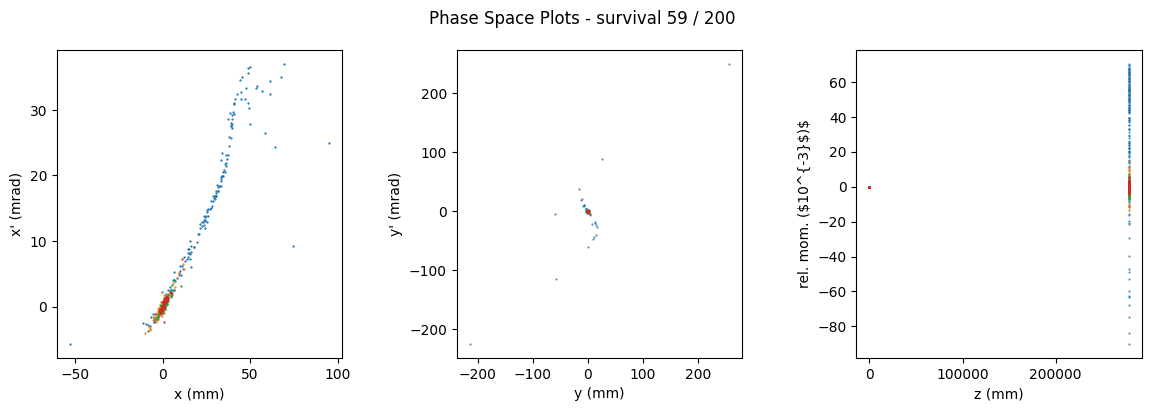

In [ ]:


n_track = 200
df_slice = df.iloc[:n_track]

# Map sliced data
x_m = df_slice['x[mm]'].values * 1e-3
y_m = df_slice['y[mm]'].values * 1e-3
px = df_slice['xp[mrad]'].values * 1e-3
py = df_slice['yp[mrad]'].values * 1e-3
zeta_m = df_slice['t[mm/c]'].values * 1e-3 

p0_mev = 2860.0 
delta = (df_slice['p[MeV/c]'].values - p0_mev) / p0_mev

p2 = xt.Particles(
    kinetic_energy0 = 2860.e6, 
    mass0 = xt.ELECTRON_MASS_EV, 
    x = x_m, 
    px = px,
    y = y_m, 
    py = py,
    zeta = zeta_m, 
    delta = delta
)

ring.configure_radiation(model='quantum')

# Since p2 is only 200 particles, turn_by_turn_monitor=True will no longer crash
ring.track(p2, num_turns=6100, turn_by_turn_monitor=True, with_progress=True)

data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]

fig = plt.figure(figsize=(14., 4.))
survival_count = np.sum(p2.state > 0)
fig.suptitle(f'Phase Space Plots - survival {survival_count} / {n_track}')

ax = fig.subplots(1, 3)
fig.subplots_adjust(wspace=0.4)

labels = [("x (mm)", "x' (mrad)"), ("y (mm)", "y' (mrad)"), ("z (mm)", r"rel. mom. ($10^{-3}$)$")]
for i, (xl, yl) in enumerate(labels):
    ax[i].set_xlabel(xl)
    ax[i].set_ylabel(yl)

for ind, turn in enumerate(trnplt):
    ax[0].scatter(1000*(data.x.T[turn] - ring_tw.dx[0]*data.delta.T[turn]), 
                  1000*(data.px.T[turn] - ring_tw.dpx[0]*data.delta.T[turn]), 
                  s=.4, c=f'C{ind}')
    
    ax[1].scatter(1000*data.y.T[turn], 1000*data.py.T[turn], s=.2, c=f'C{ind}')
    
    ax[2].scatter(1000*data.zeta.T[turn], 1000*data.delta.T[turn], s=.2, color=f'C{ind}')

plt.show()

In [ ]:

line=ring
line.config.XTRACK_USE_EXACT_DRIFTS = True
xutil.set_integrator (line)
particle = 'positron'
operation_mode = 'z'
modes = {'z': 45.6e9, # in eV 
        'w': 80e9, # in eV
        'h': 120e9, # in eV 
        't': 182.5e9 # in eV
        }
energy = modes[operation_mode]
parameters = xutil.log_parameters (None, operation_mode, particle_type=particle, modes=modes)
# ## Choose a context
context = xo.ContextCpu()         # For CPU
context_tracking = xo.ContextCpu(omp_num_threads='auto') # For CPU with activate multi-core CPU parallelization


# ## Transfer lattice on context and compile tracking code
# line.build_tracker(_context=context)

# line.configure_radiation(model='mean')
# line.compensate_radiation_energy_loss()

tw = line.twiss(eneloss_and_damping=True)

#xutil.update_reference_parameters_from_line (line, parameters, BS_scale_factor=0, update_type='all', max_bb_param=0)
# xutil.correct_parameters_conflicts(parameters, update_study_parameters_from_reference=False)

gamma0 = ring.particle_ref.gamma0[0]
beta0 = ring.particle_ref.beta0[0]

n_emittancex = 1.8e-6 * gamma0 * beta0

parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_DA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 1000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':13000e-6,
    'ini_cond_nemittance_y': 12000e-6,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


## Initial conditions
#particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)
particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])

## Tracking studies
line.configure_radiation(model='mean')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)

# dic_particles_all = xutil.tracking_data_process (tracking_data=line.record_last_track, 
#                             monitor_twiss=ring_tw.rows[0], 
#                             norm_emit_x=parameters['reference_parameters']['normalized_emittance_x'],
#                             norm_emit_y=parameters['reference_parameters']['normalized_emittance_y'],
#                             sigma_z=parameters['reference_parameters']['bunch_length'], 
#                             sigma_delta=parameters['reference_parameters']['energy_spread'],
#                             particle_id_to_use='all')
# xutil.save_dict_to_h5(f'{output_dir}/dic_particles_all.h5', dic_particles_all)


# liftime = my_xpf.particle_population_vs_turns (dic_particles_all['state'], T_rev0=tw.T_rev0)
# my_xpf.phase_space_evolution_difference (dic_particles_all['zeta'][:,0], dic_particles_all['delta'][:,0], dic_particles_all['zeta'][:,-1], dic_particles_all['delta'][:,-1], x_axis_label=r'$z~[m]$', y_axis_label=r'$\delta$')
# my_xpf.phase_space_evolution_difference (dic_particles_all['x'][:,0], dic_particles_all['px'][:,0], dic_particles_all['x'][:,-1], dic_particles_all['px'][:,-1], x_axis_label=r'$x~[m]$', y_axis_label=r'$px$')
# my_xpf.emittances_vs_turns (dic_particles_all['emit_x'], dic_particles_all['emit_y'], dic_particles_all['emit_zeta'], reference_emit_x=ref_param['emittance_x'], reference_emit_y=ref_param['emittance_y'], reference_emit_z=ref_param['energy_spread']*ref_param['bunch_length'], log_y_axis=True)
# my_xpf.coordinates_vs_turns (dic_particles_all['x_sigma'], dic_particles_all['px_sigma'], dic_particles_all['at_turn'], r'$x~[\sigma_x]$', r'$p_x~[\sigma_x]$', particle_id_list=dic_particles_all['particle_id_list'], full_init_cond=study_param['number_of_particles'])
# my_xpf.MA_vs_turns(particles, grid_details['num_r_y_points'], grid_details['num_delta'], grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
my_xpf.DA_vs_turns(particles, grid_details['num_r_y_points'], grid_details['num_theta_x_points'], grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'],delta_plots=True)
plt.xlim(-16,16)
plt.ylim(0,20)
plt.savefig(f"config_D{n}/DA_plot_{n}_WP{constants.WP}.png")

ValueError: twiss cannot be called when the radiation model is ``quantum``

Compiling ContextCpu kernels...


<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
/tmp/mwatson/ipykernel_1029825/995991698.py:65: SyntaxWarning: invalid escape sequence '\s'
  my_xpf.tune_diffusion (Qx_start['Q1']+15, Qx_end['Q1']+15, Qy_start['Q1']+15, Qy_end['Q1']+15, initial_conditions_x_axis=grid_details['x_normalized'], initial_conditions_y_axis=grid_details['y_normalized'], xlabel='x [$\sigma$]', ylabel='y [$\sigma$]', resonance_orders=(1,2,3,4), annotate=True, delta_value= None)
/tmp/mwatson/ipykernel_1029825/995991698.py:65: SyntaxWarning: invalid escape sequence '\s'
  my_xpf.tune_diffusion (Qx_start['Q1']+15, Qx_end['Q1']+15, Qy_start['Q1']+15, Qy_end['Q1']+15, initial_conditions_x_axis=grid_details['x_normalized'], initial_conditions_y_axis=grid_details['y_normalized'], xlabel='x [$\sigma$]', ylabel='y [$\sigma$]', resonance_orders=(1,2,3,4), annotate=Tru

Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
{'num_theta_x_points': 50, 'num_r_y_points': 50, 'num_delta': 1, 'num_particles': 2500, 'x_normalized': array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 2.5628088e-01,
       1.2820631e-01, 2.4492936e-16]), 'y_normalized': array([0.        , 0.        , 0.        , ..., 3.99178157, 3.99794486,
       4.        ]), 'delta_init': 0}
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/2500 [00:00<?, ?it/s]

0 / 2500
1 / 2500
2 / 2500
3 / 2500
4 / 2500
5 / 2500
6 / 2500
7 / 2500
8 / 2500
9 / 2500
10 / 2500
11 / 2500
12 / 2500
13 / 2500
14 / 2500
15 / 2500
16 / 2500
17 / 2500
18 / 2500
19 / 2500
20 / 2500
21 / 2500
22 / 2500
23 / 2500
24 / 2500
25 / 2500
26 / 2500
27 / 2500
28 / 2500
29 / 2500
30 / 2500
31 / 2500
32 / 2500
33 / 2500
34 / 2500
35 / 2500
36 / 2500
37 / 2500
38 / 2500
39 / 2500
40 / 2500
41 / 2500
42 / 2500
43 / 2500
44 / 2500
45 / 2500
46 / 2500
47 / 2500
48 / 2500
49 / 2500
50 / 2500
51 / 2500
52 / 2500
53 / 2500
54 / 2500
55 / 2500
56 / 2500
57 / 2500
58 / 2500
59 / 2500
60 / 2500
61 / 2500
62 / 2500
63 / 2500
64 / 2500
65 / 2500
66 / 2500
67 / 2500
68 / 2500
69 / 2500
70 / 2500
71 / 2500
72 / 2500
73 / 2500
74 / 2500
75 / 2500
76 / 2500
77 / 2500
78 / 2500
79 / 2500
80 / 2500
81 / 2500
82 / 2500
83 / 2500
84 / 2500
85 / 2500
86 / 2500
87 / 2500
88 / 2500
89 / 2500
90 / 2500
91 / 2500
92 / 2500
93 / 2500
94 / 2500
95 / 2500
96 / 2500
97 / 2500
98 / 2500
99 / 2500
100 / 2500

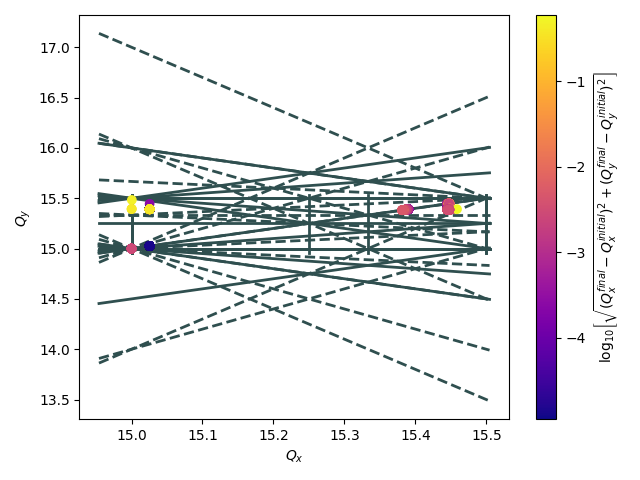

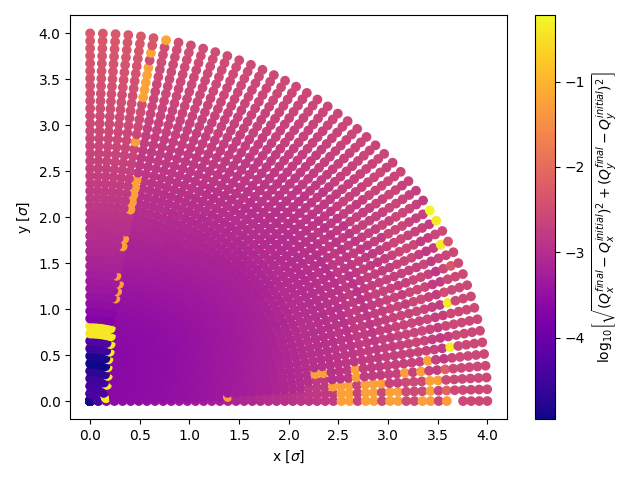

In [ ]:
%matplotlib widget

line=ring
line.config.XTRACK_USE_EXACT_DRIFTS = True
xutil.set_integrator (line)
particle = 'positron'
operation_mode = 'z'
modes = {'z': 45.6e9, # in eV 
        'w': 80e9, # in eV
        'h': 120e9, # in eV 
        't': 182.5e9 # in eV
        }
energy = modes[operation_mode]



context = xo.ContextCpu()         # For CPU
context_tracking = xo.ContextCpu(omp_num_threads='auto') # For CPU with activate multi-core CPU 
# parameters = xutil.log_parameters (None, operation_mode, particle_type=particle, modes=modes)
parameters = {}
line.configure_radiation(model=None)
parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_DA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 1000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':13000e-6,
    'ini_cond_nemittance_y': 12000e-6,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'], min_r_y=0, max_r_y=4, num_r_y_points=50, min_theta_x=0, max_theta_x=np.pi/2, 
                            num_theta_x_points=50, cartesian_polar='polar')
print(grid_details)

## Tracking studies
line.configure_radiation(model='mean')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)

Qx_start = xutil.nafflib_tune_calculation(line.record_last_track.x[:, :1000], pq_coordinates=line.record_last_track.px[:, :1000], number_harmonics=1) 
Qy_start = xutil.nafflib_tune_calculation(line.record_last_track.y[:, :1000], pq_coordinates=line.record_last_track.py[:, :1000], number_harmonics=1) 

# Window 2: Last 1000 turns (e.g., from turn 1000 to 2000)
Qx_end = xutil.nafflib_tune_calculation(line.record_last_track.x[:, 1500:2500], pq_coordinates=line.record_last_track.px[:, 1500:2500], number_harmonics=1) 
Qy_end = xutil.nafflib_tune_calculation(line.record_last_track.y[:, 1500:2500], pq_coordinates=line.record_last_track.py[:, 1500:2500], number_harmonics=1) 


my_xpf.tune_diffusion (Qx_start['Q1']+15, Qx_end['Q1']+15, Qy_start['Q1']+15, Qy_end['Q1']+15, initial_conditions_x_axis=grid_details['x_normalized'], initial_conditions_y_axis=grid_details['y_normalized'], xlabel='x [$\sigma$]', ylabel='y [$\sigma$]', resonance_orders=(1,2,3,4), annotate=True, delta_value= None)



In [ ]:
'''fp = line.get_footprint(
    nemitt_x=13000e-6, 
    nemitt_y=12000e-6,
    mode='uniform_action_grid',
    x_norm_range=(0.1, 4),  # Lowered from 6 to 4 sigmas
    y_norm_range=(0.1, 4),  # Lowered from 6 to 4 sigmas
    #n_x_norm=10, 
    #n_y_norm=10,
    freeze_longitudinal=True # Good for 4D/transverse-only footprints
)
fp.qx += 15
fp.qy += 15

# 3. Plotting
fig, ax = plt.subplots(figsize=(8,8))
fp.plot(ax=ax, color='blue', label='Amplitude Footprint')

# Set the limits to the specific integer cell
ax.set_xlim(15.0, 16.0)
ax.set_ylim(15.0, 16.0)

# Optional: Add the Twiss working point for comparison
ax.plot(ring_tw.qx, ring_tw.qy, 'ro', label='Nominal WP')
ax.legend()
'''

"fp = line.get_footprint(\n    nemitt_x=13000e-6, \n    nemitt_y=12000e-6,\n    mode='uniform_action_grid',\n    x_norm_range=(0.1, 4),  # Lowered from 6 to 4 sigmas\n    y_norm_range=(0.1, 4),  # Lowered from 6 to 4 sigmas\n    #n_x_norm=10, \n    #n_y_norm=10,\n    freeze_longitudinal=True # Good for 4D/transverse-only footprints\n)\nfp.qx += 15\nfp.qy += 15\n\n# 3. Plotting\nfig, ax = plt.subplots(figsize=(8,8))\nfp.plot(ax=ax, color='blue', label='Amplitude Footprint')\n\n# Set the limits to the specific integer cell\nax.set_xlim(15.0, 16.0)\nax.set_ylim(15.0, 16.0)\n\n# Optional: Add the Twiss working point for comparison\nax.plot(ring_tw.qx, ring_tw.qy, 'ro', label='Nominal WP')\nax.legend()\n"

In [ ]:
line.configure_radiation(model=None)

parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_MA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 1000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':13000e-6,
    'ini_cond_nemittance_y': 12000e-6,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


## Initial conditions
#particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)
particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])
print(grid_details)

## Tracking studies
line.configure_radiation(model='mean')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
{'num_theta_x_points': 1, 'num_r_y_points': 31, 'num_delta': 51, 'num_particles': 1581, 'x_normalized': array([ 0.        ,  0.70710678,  1.41421356, ..., 19.79898987,
       20.50609665, 21.21320344]), 'y_normalized': array([ 0.        ,  0.70710678,  1.41421356, ..., 19.79898987,
       20.50609665, 21.21320344]), 'delta_init': array([-0.05, -0.05, -0.05, ...,  0.05,  0.05,  0.05])}
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/2500 [00:00<?, ?it/s]

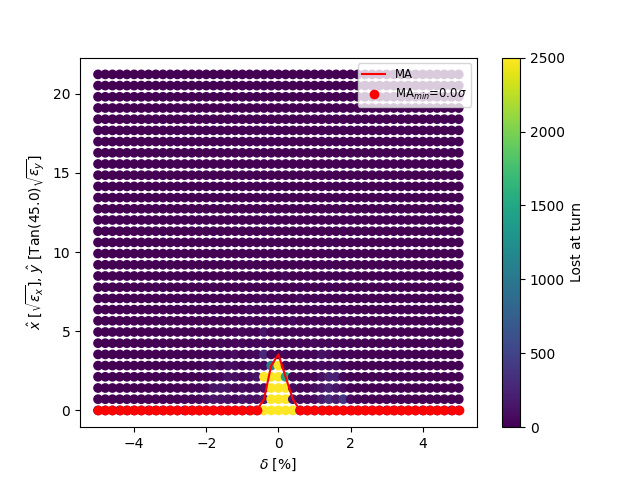

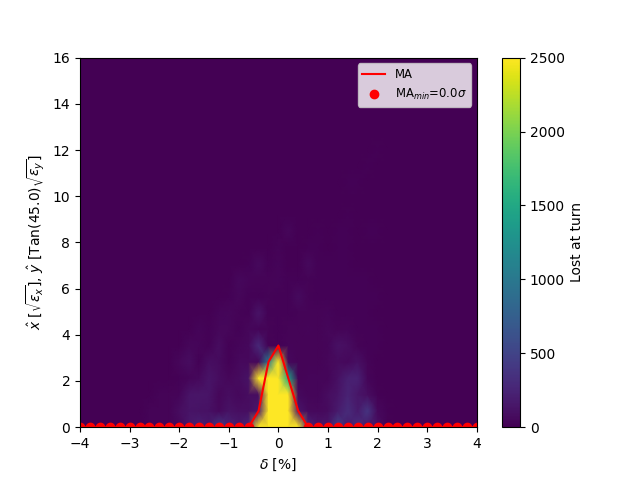

In [ ]:
my_xpf.MA_vs_turns(particles, grid_details['num_r_y_points'], 51, grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
plt.xlim(-4,4)
plt.ylim(0,16)
plt.savefig(f"config_D{n}/MA_plot_{n}_WP{constants.WP}.png")

In [ ]:

if pdf_run is True:
    pdf.close()